In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [79]:
df = pd.read_csv(
    "C:/Users/PALLAVI PUNDE/Downloads/sms+spam+collection/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [80]:
# Check the shape of the dataset
print("Dataset Shape:", df.shape)

# Check column names
print("\nColumn Names:")
print(df.columns.tolist())

# Check data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (5572, 2)

Column Names:
['label', 'message']

Data Types:
label      object
message    object
dtype: object

Missing Values:
label      0
message    0
dtype: int64


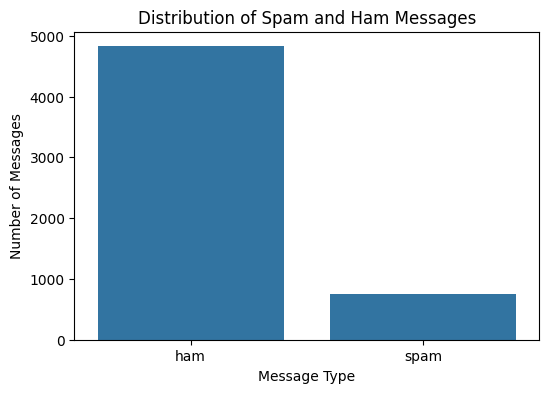

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="label")

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

In [82]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 403


In [83]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check shape after removing duplicates
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (5169, 2)


In [84]:
# Check missing values again
print("Missing values:")
print(df.isnull().sum())

Missing values:
label      0
message    0
dtype: int64


In [85]:
# Convert labels into numbers
df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [86]:
# Check the new labels
print(df["label_num"].value_counts())

label_num
0    4516
1     653
Name: count, dtype: int64


In [87]:
# Separate X and y
X = df["message"]
y = df["label_num"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5169,)
y shape: (5169,)


In [88]:
# split the dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


In [89]:
 # Convert text into numbers using TF-IDF
 from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)


Training TF-IDF shape: (4135, 5000)
Testing TF-IDF shape: (1034, 5000)


In [90]:
tfidf.fit_transform(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 29361 stored elements and shape (4135, 5000)>

In [91]:
tfidf.transform(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6526 stored elements and shape (1034, 5000)>

In [92]:
# train model using naive bayes
from sklearn.naive_bayes import MultinomialNB

# Create the model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [93]:
# make prediction
y_pred_nb = nb_model.predict(X_test_tfidf)

print("Predictions completed!")

Predictions completed!


In [94]:
# calculate accuracy
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:",
      round(nb_accuracy * 100, 2), "%")

Naive Bayes Accuracy: 97.2 %


In [95]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_nb,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       903
        Spam       1.00      0.78      0.88       131

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034



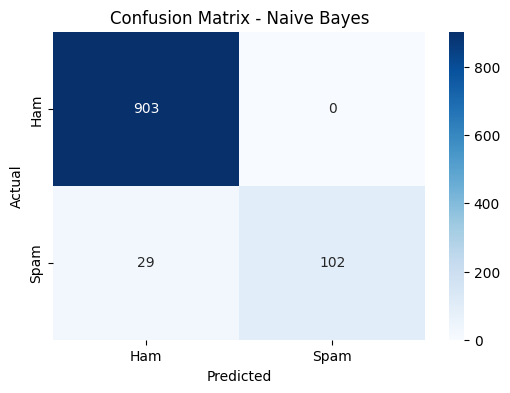

In [96]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [97]:
# train Model 2: Support Vector Machine
from sklearn.svm import SVC

# Create SVM model
svm_model = SVC(kernel="linear")

# Train the model
svm_model.fit(X_train_tfidf, y_train)

print("SVM model trained successfully!")

SVM model trained successfully!


In [98]:
# Make predictions
y_pred_svm = svm_model.predict(X_test_tfidf)

print("SVM predictions completed!")

SVM predictions completed!


In [99]:
# Calculate SVM accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:",
      round(svm_accuracy * 100, 2), "%")

SVM Accuracy: 97.68 %


In [100]:
# Classification report
print("SVM Classification Report:\n")

print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["Ham", "Spam"]
))

SVM Classification Report:

              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       903
        Spam       0.95      0.86      0.90       131

    accuracy                           0.98      1034
   macro avg       0.96      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



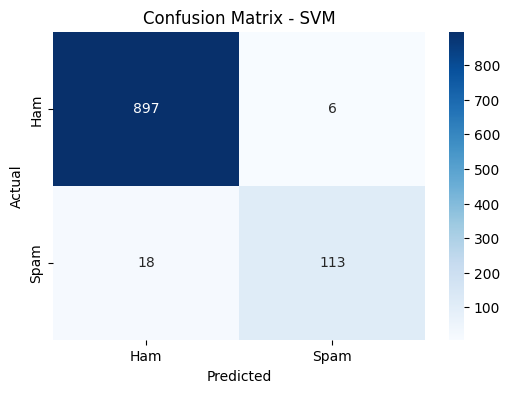

In [101]:
 # SVM Confusion Matrix
 cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [102]:
# Compare both models
comparison = pd.DataFrame({
    "Model": ["Multinomial Naive Bayes", "SVM"],
    "Accuracy": [
        nb_accuracy * 100,
        svm_accuracy * 100
    ]
})

comparison

,Model,Accuracy
0,Multinomial Naive Bayes,97.195358
1,SVM,97.678917


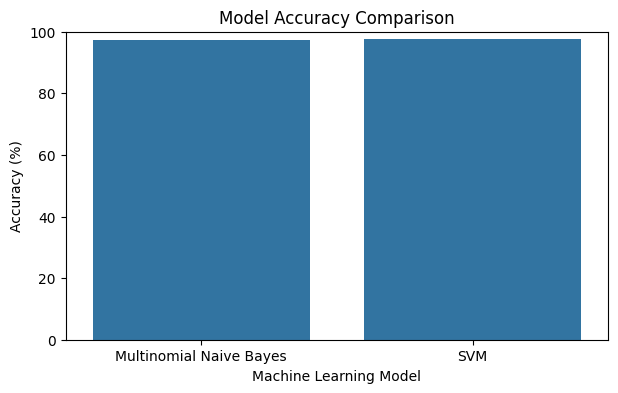

In [103]:
#
plt.figure(figsize=(7, 4))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Machine Learning Model")
plt.ylim(0, 100)

plt.show()

In [ ]:
# identify the best model
best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print("Best Model:", best_model["Model"])
print("Best Accuracy:", round(best_model["Accuracy"], 2), "%")

Best Model: SVM
Best Accuracy: 97.68 %
